# First-order system: the infinite horizon vs a long finite horizon

The model is the canonical declared first-order system from
[`models/first_order.py`](models/first_order.py): see the module for its
construction. Two cases of the same model. Case 1 runs five sampling steps
with the infinite-horizon terminal segment (`drto.infinite_horizon`) carrying
the tail, which deactivates the declared terminal cost since the tail owns
the cost-to-go. Case 2 runs fifty steps of plain finite horizon with the
terminal cost live.

## Case 1: five samples plus the infinite-horizon tail

In [1]:
import pyomo.environ as pyo
import drto
from models.first_order import first_order
from plotting import plot_states, plot_controls, plot_stage_cost

m1 = first_order(N=5)
pyo.TransformationFactory("dae.collocation").apply_to(m1, wrt=m1.t, nfe=5, ncp=3, scheme="LAGRANGE-RADAU")
pyo.TransformationFactory("drto.infinite_horizon").apply_to(
    m1,
    nfe=3,                    # finite elements on the terminal segment
    ncp=5,                    # Gauss-Legendre points per element
    beta=1.2,                 # tail overestimation factor, > 1
    gamma="rule",             # the mesh rule, tanh(gamma*h) = tau_11; pass a number to override
    profile="collocation",    # segment control profile (pyomo-cvp)
)
pyo.TransformationFactory("drto.parameterize").apply_to(m1)  # the finite-horizon profiles
drto.build_objective(m1)
pyo.SolverFactory("pounce").solve(m1, tee=True)

********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) â€” drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.8.0, running with linear solver FERAL.

Reading C:\Users\Devin\AppData\Local\Temp\tmp2x0gu0ji.pyomo.nl...
Parsed 91 vars, 7

iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
   0  2.4395512e+01 1.00e-01 9.01e+00   -1.0 0.00e+00      - 0.00e+00 0.00e+00   0
   1  2.3111414e+00 2.27e-02 1.00e+01   -1.0 1.00e-01    2.0 1.00e+00 1.00e+00f  1
   2  2.1496800e-01 4.32e-03 4.78e-01   -1.0 4.73e-01      - 1.00e+00 1.00e+00f  1
   3  3.5278242e-02 2.30e-02 3.23e-03   -1.7 4.33e-01      - 9.69e-01 1.00e+00h  1
   4  1.1365031e-01 6.38e-04 1.49e-14   -2.5 4.29e-02      - 1.00e+00 1.00e+00h  1
   5  1.1521753e-01 5.18e-06 2.14e-14   -3.8 4.44e-03      - 1.00e+00 1.00e+00h  1
   6  1.1522666e-01 6.13e-09 3.80e-15   -5.7 8.51e-05      - 1.00e+00 1.00e+00h  1
   7  1.1522667e-01 4.30e-13 1.94e-14   -8.6 5.20e-07      - 1.00e+00 1.00e+00h  1


Number of Iterations....: 7

                                   (scaled)                 (unscaled)
Objective...............:   5.8998043725977202e-02    1.1522667314934305e-01
Dual infeasibility......:   1.9411972436390521e-14    1.9411972436390521e-

{'Problem': [{'Lower bound': -inf, 'Upper bound': inf, 'Number of objectives': 1, 'Number of constraints': 75, 'Number of variables': 91, 'Sense': 'unknown'}], 'Solver': [{'Status': 'ok', 'Message': 'POUNCE 0.8.0\\x3a SolveSucceeded', 'Termination condition': 'optimal', 'Id': 0, 'Error rc': 0, 'Time': 0.8437056541442871}], 'Solution': [OrderedDict({'number of solutions': 0, 'number of solutions displayed': 0})]}

In [2]:
drto.info(m1)

horizon,"t (ContinuousSet, 16 points)"
states,z (free)
dynamics,dzdt[t] == (- z[t] + u[t])/tau_p for t in t
controls,"u (piecewise_constant, free)"
tracking stage cost,cost[t] == 10*(z[t] - z_ss)**2 + (u[t] - u_ss)**2 for t in sorted(t)[:-1]
terminal cost,term == 10*(z[5] - z_ss)**2
initial conditions,z[0] == z_hat
steady-state targets,z_ss (of z)
steady-state control targets,u_ss (of u)
cost_group,drto_infinite_horizon


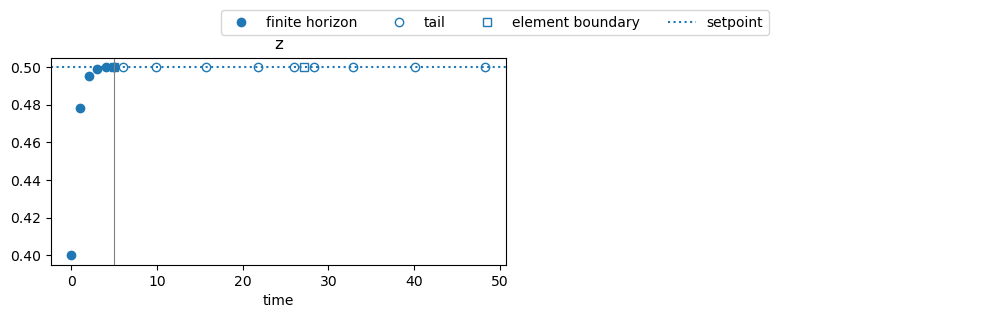

In [3]:
plot_states(m1);

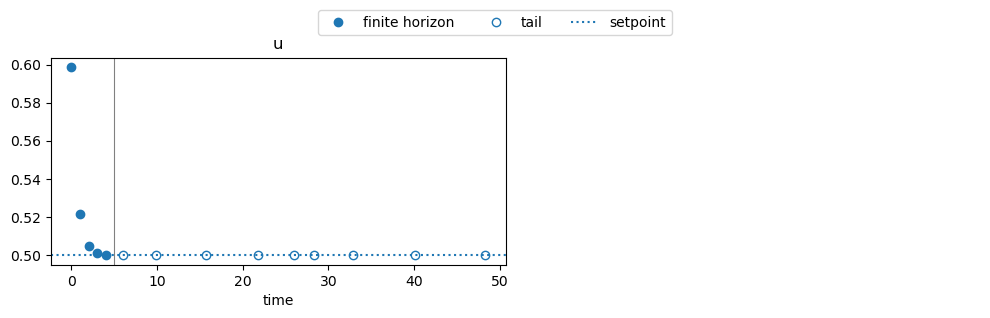

In [4]:
plot_controls(m1);

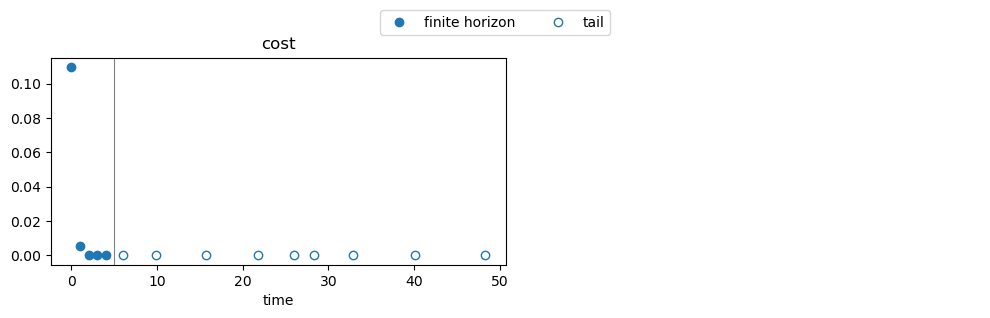

In [5]:
plot_stage_cost(m1);

## Case 2: fifty samples, finite horizon with the terminal cost

In [6]:
m2 = first_order(N=50)
pyo.TransformationFactory("dae.collocation").apply_to(m2, wrt=m2.t, nfe=50, ncp=3, scheme="LAGRANGE-RADAU")
pyo.TransformationFactory("drto.parameterize").apply_to(m2)
drto.build_objective(m2)
pyo.SolverFactory("pounce").solve(m2, tee=True)

********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) â€” drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.8.0, running with linear solver FERAL.

Reading C:\Users\Devin\AppData\Local\Temp\tmp49xji71z.pyomo.nl...
pounce: wrote C:\

Parsed 403 vars, 353 cons, jac_nnz=1356, h_nnz=101 in 0.02s
Problem class: NLP. Selected solver: NLP filter line-search interior-point (pounce-nlp) [solver_selection=auto].

Number of nonzeros in equality constraint Jacobian...:     1356
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:      101

Total number of variables............................:      403
                     variables with only lower bounds:        0
                variables with lower and upper bounds:       50
                     variables with only upper bounds:        0
Total number of equality constraints.................:      353
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg

{'Problem': [{'Lower bound': -inf, 'Upper bound': inf, 'Number of objectives': 1, 'Number of constraints': 353, 'Number of variables': 403, 'Sense': 'unknown'}], 'Solver': [{'Status': 'ok', 'Message': 'POUNCE 0.8.0\\x3a SolveSucceeded', 'Termination condition': 'optimal', 'Id': 0, 'Error rc': 0, 'Time': 0.7398841381072998}], 'Solution': [OrderedDict({'number of solutions': 0, 'number of solutions displayed': 0})]}

In [7]:
drto.info(m2)

horizon,"t (ContinuousSet, 151 points)"
states,z (free)
dynamics,dzdt[t] == (- z[t] + u[t])/tau_p for t in t
controls,"u (piecewise_constant, free)"
tracking stage cost,cost[t] == 10*(z[t] - z_ss)**2 + (u[t] - u_ss)**2 for t in sorted(t)[:-1]
terminal cost,term == 10*(z[50] - z_ss)**2
initial conditions,z[0] == z_hat
steady-state targets,z_ss (of z)
steady-state control targets,u_ss (of u)


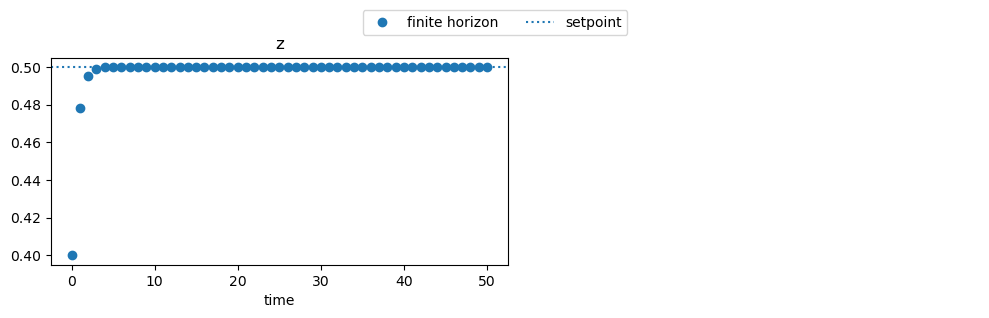

In [8]:
plot_states(m2);

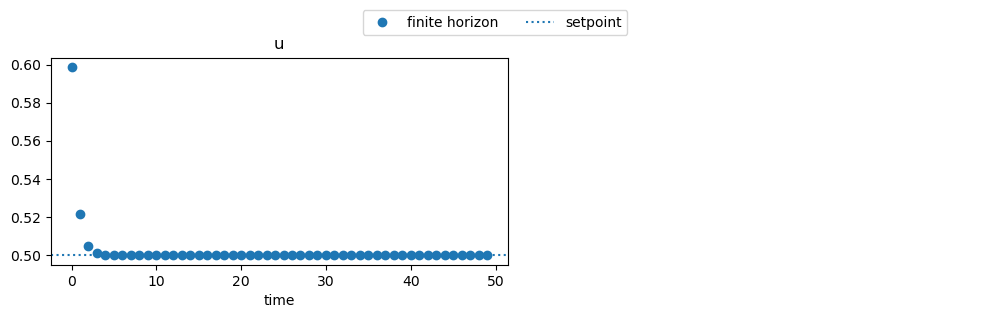

In [9]:
plot_controls(m2);

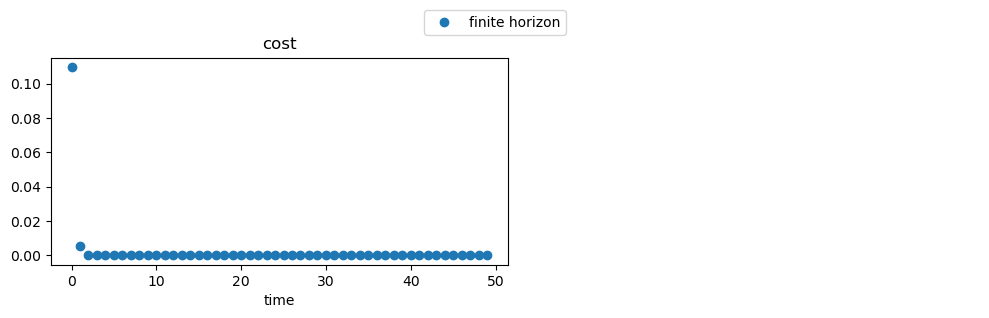

In [10]:
plot_stage_cost(m2);